# Retrieval Evaluation

**Goal:** compare the project's S-PubMedBert + ChromaDB retrieval against a TF-IDF baseline on 20 sampled MedQuAD questions. Primary metric: Recall@5.

**Compared retrievers:**

1. **ChromaDB (project)**: `src.pipeline.chromadb_store.query()`. PubMedBert encode of the query, cosine search over the persistent index, dedup on normalized text fingerprint.
2. **TF-IDF baseline**: `TfidfVectorizer.fit_transform` over the _same_ document set ChromaDB indexes, cosine similarity at query time.

**Method:**

- Sample 20 MedQuAD rows with `random_state=42`. For each, the `question` field is the query string and the originating MedQuAD doc id is the single expected relevant document (the answer we score against).
- Retrieve top-10 from each method. Compute Recall@k for k in (1, 3, 5, 10).

**Caveat:** MedQuAD's `text` field (what ChromaDB indexes) is built as `question + answer`. So the query string is literally a substring of the expected document. Both retrievers face the same condition, so the comparison is fair, but absolute Recall numbers will be high. The interesting quantity is the **margin** between the two methods, not the absolute values.


In [1]:
import json
import random
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

# Project import path: notebooks/ lives one level under the repo root
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from src.utils.config import RAG_SOURCES, RESULTS_DIR
from src.pipeline import chromadb_store

In [2]:
# Pull MedQuAD rows. We need the question (for the query) and the row's id
# (which maps to the ChromaDB id as f"medquad_{row_id}" per Phase 5 build).
medquad_rows = []
with open(RAG_SOURCES["medquad"], encoding="utf-8") as f:
    for line in f:
        medquad_rows.append(json.loads(line))
print(f"Loaded {len(medquad_rows):,} MedQuAD rows")

# Sample 20 rows with a fixed seed so the eval is reproducible run to run
rng = random.Random(42)
sample = rng.sample(medquad_rows, 20)
queries = [r["question"] for r in sample]
expected_doc_ids = [f"medquad_{r['id']}" for r in sample]
print(f"Sampled {len(sample)} questions   first expected doc id: {expected_doc_ids[0]}")

Loaded 16,359 MedQuAD rows
Sampled 20 questions   first expected doc id: medquad_10476


## Sample queries

First 5 of the 20 sampled questions, alongside their expected doc id and a snippet of the answer the retriever is being asked to recover.


In [3]:
preview = pd.DataFrame(
    [
        {
            "expected_doc_id": expected_doc_ids[i],
            "qtype": sample[i].get("qtype", ""),
            "question": queries[i][:80] + ("..." if len(queries[i]) > 80 else ""),
            "answer_snippet": (
                (str(sample[i].get("answer", ""))[:80] + "...")
                if len(str(sample[i].get("answer", ""))) > 80
                else str(sample[i].get("answer", ""))
            ),
        }
        for i in range(5)
    ]
)
preview

,expected_doc_id,qtype,question,answer_snippet
0,medquad_10476,frequency,How many people are affected by Refsum disease ?,"The prevalence of Refsum disease is unknown, a..."
1,medquad_1824,considerations,What to do for Urine Blockage in Newborns ?,Researchers have not found that a mothers eati...
2,medquad_409,research,what research (or clinical trials) is being do...,The mission of the National Institute of Neuro...
3,medquad_12149,causes,What causes Congenital laryngeal palsy ?,What is the cause of congenital laryngeal para...
4,medquad_4506,symptoms,What are the symptoms of Cardiomyopathy ?,Some people who have cardiomyopathy never have...


## Building the TF-IDF baseline

The baseline must search the _same_ corpus ChromaDB does. We pull every document straight out of the persistent ChromaDB collection (no re-loading from source files), then fit `TfidfVectorizer` on that text. Both retrievers index the same set, so the comparison is apples-to-apples.


In [4]:
# Pull ALL docs from the ChromaDB collection (~55k). This is the same set that
# the project's ChromaDB retriever searches at runtime, so the baseline is on
# the identical corpus.
t0 = time.perf_counter()
coll = chromadb_store.get_collection()
all_data = coll.get(include=["documents"])
all_ids = all_data["ids"]
all_docs = all_data["documents"]
print(f"Pulled {len(all_ids):,} docs from ChromaDB in {time.perf_counter() - t0:.1f}s")

# Quick sanity check: every expected doc id should be present in the corpus
missing = [d for d in expected_doc_ids if d not in set(all_ids)]
if missing:
    print(
        f"WARNING: {len(missing)} expected doc ids not found in collection: {missing[:3]}"
    )
else:
    print("All 20 expected doc ids present in the collection.")

# Map id -> row index in all_docs so we can recover ids from top-k indices
id_to_idx = {doc_id: i for i, doc_id in enumerate(all_ids)}

Pulled 55,949 docs from ChromaDB in 1.2s
All 20 expected doc ids present in the collection.


In [5]:
# Fit TF-IDF on the full corpus. Defaults are reasonable for biomedical text;
# unigrams + bigrams, English stopwords removed, sublinear TF for length
# robustness. min_df=2 to drop one-off typos/IDs without throwing away rare
# clinical terms.
t0 = time.perf_counter()
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    sublinear_tf=True,
    min_df=2,
)
doc_vectors = vectorizer.fit_transform(all_docs)
print(f"TF-IDF fit: {time.perf_counter() - t0:.1f}s   shape={doc_vectors.shape}")

TF-IDF fit: 10.6s   shape=(55949, 803533)


## Retrieve top-10 from each method

Top-10 (rather than just top-5) so we can compute R@1, R@3, R@5, and R@10 from one pass. ChromaDB query goes through the project wrapper (which over-fetches and dedups internally before returning the requested k). TF-IDF baseline is plain cosine similarity over the fitted matrix.


In [6]:
def chromadb_top_ids(q: str, k: int = 10) -> list[str]:
    """Run the project wrapper for the query and return ids in rank order."""
    hits = chromadb_store.query(q, k=k)
    return [h["id"] for h in hits]


def tfidf_top_ids(q: str, k: int = 10) -> list[str]:
    """Cosine-similarity top-k over the fitted doc_vectors matrix."""
    qv = vectorizer.transform([q])
    # 1 x n_docs similarity row; ravel for argsort
    sims = cosine_similarity(qv, doc_vectors).ravel()
    # argpartition is O(n) for top-k; argsort only the k winners for final order
    top_k_unsorted = np.argpartition(-sims, k)[:k]
    top_k = top_k_unsorted[np.argsort(-sims[top_k_unsorted])]
    return [all_ids[i] for i in top_k]


t0 = time.perf_counter()
chroma_results = [chromadb_top_ids(q, k=10) for q in queries]
t_chroma = time.perf_counter() - t0

t0 = time.perf_counter()
tfidf_results = [tfidf_top_ids(q, k=10) for q in queries]
t_tfidf = time.perf_counter() - t0

print(
    f"ChromaDB: {t_chroma:.1f}s   TF-IDF: {t_tfidf:.1f}s   (across {len(queries)} queries)"
)

W0517 03:55:17.014000 30452 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ChromaDB: 17.8s   TF-IDF: 3.2s   (across 20 queries)


## Per-model metrics

Recall@k counts a query as a hit if the expected doc id appears anywhere in the top-k. Because we have exactly one expected doc per query, Recall@k for a single query is binary; the reported mean is just the fraction of queries hit.


In [7]:
K_VALUES = [1, 3, 5, 10]


def recall_at_k(retrieved_lists: list[list[str]], expected: list[str], k: int) -> float:
    """Mean Recall@k across queries. One expected doc per query, so each query is 0 or 1."""
    hits = sum(
        1 for retrieved, e in zip(retrieved_lists, expected) if e in retrieved[:k]
    )
    return hits / len(expected)


metrics_chroma = {k: recall_at_k(chroma_results, expected_doc_ids, k) for k in K_VALUES}
metrics_tfidf = {k: recall_at_k(tfidf_results, expected_doc_ids, k) for k in K_VALUES}

print("Recall@k")
print(f"  {'k':<6}{'ChromaDB':>12}{'TF-IDF':>12}{'delta':>10}")
for k in K_VALUES:
    c = metrics_chroma[k]
    t = metrics_tfidf[k]
    print(f"  {k:<6}{c:>12.4f}{t:>12.4f}{c - t:>+10.4f}")

Recall@k
  k         ChromaDB      TF-IDF     delta
  1           0.7000      0.4000   +0.3000
  3           0.8000      0.5500   +0.2500
  5           0.9500      0.8500   +0.1000
  10          0.9500      0.9000   +0.0500


In [8]:
# Per-query result table. rank_X is the 1-indexed position of the expected doc id
# in that method's top-10, or '-' if it did not appear at all.
def expected_rank(retrieved: list[str], expected: str) -> str:
    """1-indexed rank of `expected` inside `retrieved`, or '-' if not in top-10."""
    try:
        return str(retrieved.index(expected) + 1)
    except ValueError:
        return "-"


rows = []
for i, (q, e, cr, tr) in enumerate(
    zip(queries, expected_doc_ids, chroma_results, tfidf_results)
):
    rows.append(
        {
            "i": i,
            "question": q[:60] + ("..." if len(q) > 60 else ""),
            "expected_doc_id": e,
            "rank_chroma": expected_rank(cr, e),
            "rank_tfidf": expected_rank(tr, e),
        }
    )
per_query = pd.DataFrame(rows)
per_query

,i,question,expected_doc_id,rank_chroma,rank_tfidf
0,0,How many people are affected by Refsum disease ?,medquad_10476,1,1
1,1,What to do for Urine Blockage in Newborns ?,medquad_1824,1,1
2,2,what research (or clinical trials) is being do...,medquad_409,2,1
3,3,What causes Congenital laryngeal palsy ?,medquad_12149,1,4
4,4,What are the symptoms of Cardiomyopathy ?,medquad_4506,1,2
5,5,How to prevent Respiratory Distress Syndrome ?,medquad_4012,1,4
6,6,What is (are) Diabetes ?,medquad_3657,-,-
7,7,What causes Growth Failure in Children with Ch...,medquad_2286,3,4
8,8,How to diagnose Desmoplastic infantile ganglio...,medquad_12066,1,1
9,9,What are the complications of Polycystic Kidne...,medquad_1679,4,-


## Comparison chart

Recall@k for k in (1, 3, 5, 10), grouped by retriever. Saved as a PNG for the report.


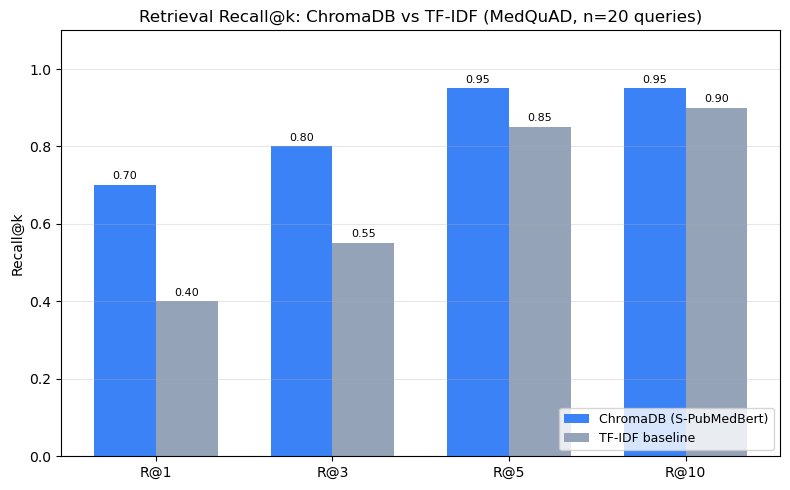

In [9]:
import matplotlib.pyplot as plt

# results/ is the project's standard artifact directory
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
chart_path = RESULTS_DIR / "retrieval_eval_chart.png"

# x-axis: one slot per k value
x_positions = list(range(len(K_VALUES)))
bar_width = 0.35  # two bars per slot, half width each

chroma_vals = [metrics_chroma[k] for k in K_VALUES]
tfidf_vals = [metrics_tfidf[k] for k in K_VALUES]

fig, ax = plt.subplots(figsize=(8, 5))

bars_c = ax.bar(
    [i - bar_width / 2 for i in x_positions],
    chroma_vals,
    bar_width,
    label="ChromaDB (S-PubMedBert)",
    color="#3b82f6",
)
bars_t = ax.bar(
    [i + bar_width / 2 for i in x_positions],
    tfidf_vals,
    bar_width,
    label="TF-IDF baseline",
    color="#94a3b8",
)

# Numeric labels on top of every bar so the reader does not have to eyeball the y axis
for group in (bars_c, bars_t):
    for bar in group:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(x_positions)
ax.set_xticklabels([f"R@{k}" for k in K_VALUES])
ax.set_ylim(0, 1.1)
ax.set_ylabel("Recall@k")
ax.set_title(
    f"Retrieval Recall@k: ChromaDB vs TF-IDF (MedQuAD, n={len(queries)} queries)"
)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right", fontsize=9)

fig.tight_layout()
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()